# 09 Identification of Branch-Defining Sites

**Methods mapping:** branch-defining HVR2 site identification.

This notebook reruns the linked-site screen from the raw LoFreq CSV and combines it with haplotype sequences and TreeCluster branch assignments. It translates the affected codons, keeps amino-acid states that differ between paired branches, and draws Fig. 4A-B.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('09_branch_defining_sites', ROOT)
INPUTS = {
    "lofreq_raw_calls": ROOT / "data/input/isnv/lofreq_raw_calls.csv",
    "metadata": ROOT / "data/metadata/meta_v6_with_season_clade.csv",
    "AU_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1037681_extracted_4652-5617.fasta",
    "US_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1130896_extracted_4652-5617.fasta",
}
OUTPUTS = {
    "core_linked_nt_sites": DATA_DIR / "core_linked_nt_sites_used.csv",
    "hvr2_aa_matrix": DATA_DIR / "hvr2_core_aa_site_matrix.csv",
    "aa_site_summary": DATA_DIR / "branch_defining_aa_site_summary.csv",
    "domain_layout": DATA_DIR / "g_protein_domain_layout.csv",
    "figure_png": FIG_DIR / "Fig4AB_branch_defining_HVR2_sites.png",
    "figure_pdf": FIG_DIR / "Fig4AB_branch_defining_HVR2_sites.pdf",
    "figure_svg": FIG_DIR / "Fig4AB_branch_defining_HVR2_sites.svg",
}


def show_paths(title, paths):
    rows = []
    for name, path in paths.items():
        path = Path(path)
        rows.append({"name": name, "relative_path": rel(path), "exists": path.exists()})
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))

for path in OUTPUTS.values():
    Path(path).parent.mkdir(parents=True, exist_ok=True)

show_paths("Input paths", INPUTS)
show_paths("Output paths", OUTPUTS)
DATA_DIR, FIG_DIR


### Input paths

,name,relative_path,exists
0,lofreq_raw_calls,data/input/isnv/lofreq_raw_calls.csv,True
1,metadata,data/metadata/meta_v6_with_season_clade.csv,True
2,AU_haplotype_fasta,data/input/haplotypes/PRJNA1037681_...,True
3,US_haplotype_fasta,data/input/haplotypes/PRJNA1130896_...,True


### Output paths

,name,relative_path,exists
0,core_linked_nt_sites,data/processed_data/09_branch_defining_s...,True
1,hvr2_aa_matrix,data/processed_data/09_branch_defining_s...,True
2,aa_site_summary,data/processed_data/09_branch_defining_s...,True
3,domain_layout,data/processed_data/09_branch_defining_s...,True
4,figure_png,results/figures/09_branch_defining_...,True
5,figure_pdf,results/figures/09_branch_defining_...,True
6,figure_svg,results/figures/09_branch_defining_...,True


(PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/data/processed_data/09_branch_defining_sites'),
 PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/results/figures/09_branch_defining_sites'))

## Check Branch Assignments and Sites

These branch pairs and nucleotide sites are recalculated from input files before the amino-acid matrix is built.


In [3]:
targets = au.select_target_branch_combos(ROOT)
site_sets = au.derive_linked_site_sets(ROOT)
site_table = pd.DataFrame([
    {'project': project, 'position': site['position'], 'ref': site['ref'], 'alt': site['alt']}
    for project, sites in site_sets.items()
    for site in sites
])

display(targets)
display(site_table)


,project,project_label,target_combo,target_branches,n_target_samples,selection_rule
0,PRJNA1037681,Australia,C4+C6,"[C4, C6]",23,most frequent exact cross-branch TreeCluster c...
1,PRJNA1130896,United States,C18+C21,"[C18, C21]",26,most frequent exact cross-branch TreeCluster c...


,project,position,ref,alt
0,PRJNA1037681,5510,G,A
1,PRJNA1037681,5520,A,T
2,PRJNA1037681,5544,C,T
3,PRJNA1037681,5558,G,A
4,PRJNA1037681,5563,T,C
5,PRJNA1130896,5531,T,C
6,PRJNA1130896,5561,T,C


## Rebuild Branch-Defining Amino-Acid States

Empty cells in the amino-acid matrix are intentional: those positions were either not part of that cohort's branch pair or did not change the amino acid.


In [4]:
core, matrix, aa_summary = au.branch_defining_sites(ROOT, DATA_DIR)

display(core)
display(matrix)
display(aa_summary)


,project,validation_sample_set,TreeCluster_combo,nt_position_genome,ref_nt,target_nt,aa_position,lofreq_status,samples,median_alt_frequency_percent,min_alt_frequency_percent,max_alt_frequency_percent,median_depth
0,PRJNA1037681,AU linked iSNV validation set,C4+C6,5510,G,A,287,called_target_alt,23,4.95570,2.7127,8.5859,827.0
1,PRJNA1037681,AU linked iSNV validation set,C4+C6,5520,A,T,290,called_target_alt,23,6.22990,3.1716,10.6090,799.0
2,PRJNA1037681,AU linked iSNV validation set,C4+C6,5544,C,T,298,called_target_alt,23,93.01310,86.8119,95.7921,729.0
3,PRJNA1037681,AU linked iSNV validation set,C4+C6,5558,G,A,303,called_target_alt,23,94.91760,89.5906,97.3594,759.0
4,PRJNA1037681,AU linked iSNV validation set,C4+C6,5563,T,C,304,called_target_alt,23,4.48180,2.3364,9.3836,763.0
5,PRJNA1130896,US linked iSNV validation set,C18+C21,5531,T,C,294,called_target_alt,26,87.04055,74.3728,91.5636,3807.0
6,PRJNA1130896,US linked iSNV validation set,C18+C21,5561,T,C,304,called_target_alt,26,85.07980,69.7757,91.1309,3088.0


,project,project_label,TreeCluster_combo,branch,n_samples_total,AA287,AA290,AA294,AA298,AA303,AA304
0,PRJNA1037681,Australia,C4+C6,C4,23,E,H,NaN,L,I,NaN
1,PRJNA1037681,Australia,C4+C6,C6,23,K,L,NaN,P,V,NaN
2,PRJNA1130896,United States,C18+C21,C18,26,NaN,NaN,S,NaN,NaN,Y
3,PRJNA1130896,United States,C18+C21,C21,26,NaN,NaN,P,NaN,NaN,H


,project,project_label,TreeCluster_combo,branch_a,branch_b,aa_position,branch_a_state,branch_b_state,aa_change,n_samples_total
0,PRJNA1037681,Australia,C4+C6,C4,C6,287,E,K,E>K,23
1,PRJNA1037681,Australia,C4+C6,C4,C6,290,H,L,H>L,23
2,PRJNA1037681,Australia,C4+C6,C4,C6,298,L,P,L>P,23
3,PRJNA1037681,Australia,C4+C6,C4,C6,303,I,V,I>V,23
4,PRJNA1130896,United States,C18+C21,C18,C21,294,S,P,S>P,26
5,PRJNA1130896,United States,C18+C21,C18,C21,304,Y,H,Y>H,26


## Figure

Fig. 4A-B is drawn from the regenerated core nucleotide-site table and amino-acid state matrix.


{'png': 'results/figures/09_branch_defining_sites/Fig4AB_branch_defining_HVR2_sites.png',
 'pdf': 'results/figures/09_branch_defining_sites/Fig4AB_branch_defining_HVR2_sites.pdf',
 'svg': 'results/figures/09_branch_defining_sites/Fig4AB_branch_defining_HVR2_sites.svg'}

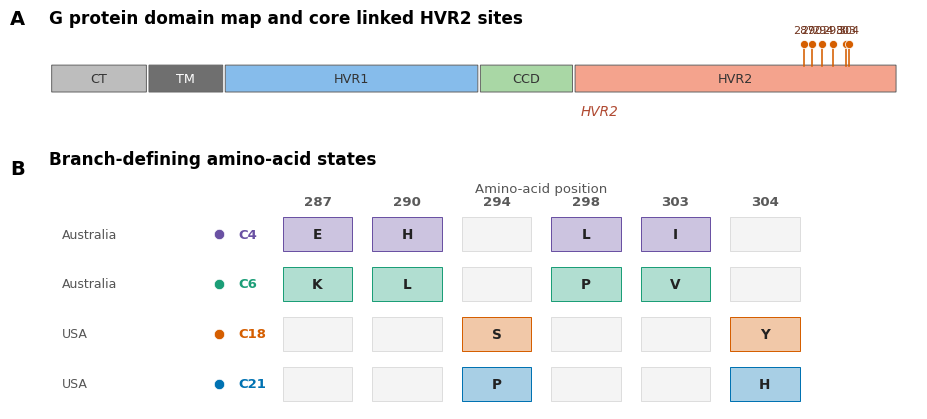

In [5]:
fig, paths = au.draw_branch_defining_sites(ROOT, core, matrix, FIG_DIR)
display(paths)
plt.show()
